Dataset: https://www.kaggle.com/datasets/blastchar/telco-customer-churn


GitHub: https://github.com/Lucem-nacho/Proyecto-Rotaci-n-de-clientes-de-telecomunicaciones.git

📊 Análisis y Preparación del Dataset: Telco Customer Churn
Objetivo: Explorar los datos crudos del sector de telecomunicaciones, identificar errores de tipado críticos (como el caso de TotalCharges) y definir un flujo de limpieza que permita predecir la fuga de clientes de manera confiable.

**📖 Diccionario de Variables Clave (Selección de 10)**

**1-gender: Género del cliente (Male/Female).**

**2-SeniorCitizen: Si el cliente es adulto mayor (0: No, 1: Sí).**

**3-Partner: Si el cliente tiene pareja (Yes/No).**

**4-tenure: Meses que el cliente ha permanecido en la compañía. (Variable clave para lealtad).**

**5-InternetService: Tipo de servicio de internet (DSL, Fiber optic, No).**

**6-Contract: Tipo de contrato (Month-to-month, One year, Two year).**

**7-PaymentMethod: Método de pago (Electronic check, Mailed check, Bank transfer, Credit card).**

**8-MonthlyCharges: Monto facturado mensualmente al cliente.**

**9-TotalCharges: Monto total facturado durante toda la permanencia. (Variable crítica para limpieza).**

**10-Churn (Variable Objetivo): Indica si el cliente canceló el servicio en el último mes ('Yes' o 'No').**

In [37]:
import pandas as pd   # Manipulación de datos
import numpy as np    # Operaciones matemáticas y manejo de nulos
import matplotlib.pyplot as plt # Visualización
import seaborn as sns # Visualización estadística

In [38]:
# Carga el archivo original
df_raw = pd.read_csv('WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [39]:
display(df_raw.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


None

In [40]:
display(df_raw.describe())

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [41]:
display(df_raw.describe(include=['object']))

,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,3186-AJIEK,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [42]:
# Seleccionamos nuestras 10 columnas estratégicas
columnas_estudio = [
    'gender', 'SeniorCitizen', 'Partner', 'tenure', 'InternetService',
    'Contract', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'
]
df = df_raw[columnas_estudio].copy()
df.head(3)

,gender,SeniorCitizen,Partner,tenure,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,1,DSL,Month-to-month,Electronic check,29.85,29.85,No
1,Male,0,No,34,DSL,One year,Mailed check,56.95,1889.5,No
2,Male,0,No,2,DSL,Month-to-month,Mailed check,53.85,108.15,Yes


# Liempieza de datos

--- Espacios en blanco detectados en TotalCharges: 11 ---


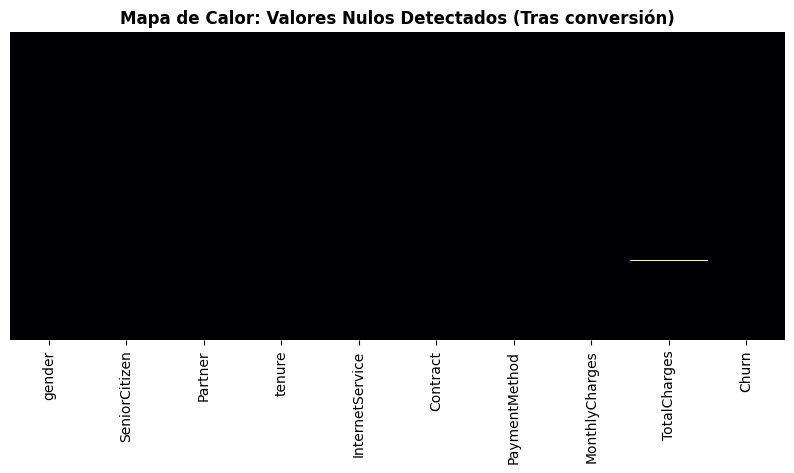

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Identificar espacios en blanco que parecen nulos
# Usamos .str.isspace() para detectar celdas que solo tienen " "
espacios_blanco = df['TotalCharges'].astype(str).str.isspace().sum()
print(f"--- Espacios en blanco detectados en TotalCharges: {espacios_blanco} ---")

# 2. Emular el Mapa de Calor para tu contexto
# Primero convertimos esos espacios a NaN reales para que el gráfico los detecte
df_temp = df.copy()
df_temp['TotalCharges'] = pd.to_numeric(df_temp['TotalCharges'], errors='coerce')

# Ahora graficamos los NaN (nulos reales)
plt.figure(figsize=(10, 4))
sns.heatmap(df_temp.isnull(), cbar=False, cmap="magma", yticklabels=False)

plt.title("Mapa de Calor: Valores Nulos Detectados (Tras conversión)", fontweight='bold')
plt.show()

In [44]:
# Convertimos TotalCharges a numérico, los espacios en blanco se transformarán en NaN automáticamente con errors='coerce'
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Verificamos el resultado y el conteo de nulos finales
print(f"Nulos detectados en TotalCharges: {df['TotalCharges'].isnull().sum()}")
print(f"Nuevo tipo de dato: {df['TotalCharges'].dtype}")
display(df.head())
display(df.info())

Nulos detectados en TotalCharges: 11
Nuevo tipo de dato: float64


,gender,SeniorCitizen,Partner,tenure,InternetService,Contract,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,1,DSL,Month-to-month,Electronic check,29.85,29.85,No
1,Male,0,No,34,DSL,One year,Mailed check,56.95,1889.50,No
2,Male,0,No,2,DSL,Month-to-month,Mailed check,53.85,108.15,Yes
3,Male,0,No,45,DSL,One year,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,2,Fiber optic,Month-to-month,Electronic check,70.70,151.65,Yes


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender           7043 non-null   object 
 1   SeniorCitizen    7043 non-null   int64  
 2   Partner          7043 non-null   object 
 3   tenure           7043 non-null   int64  
 4   InternetService  7043 non-null   object 
 5   Contract         7043 non-null   object 
 6   PaymentMethod    7043 non-null   object 
 7   MonthlyCharges   7043 non-null   float64
 8   TotalCharges     7032 non-null   float64
 9   Churn            7043 non-null   object 
dtypes: float64(2), int64(2), object(6)
memory usage: 550.4+ KB


None

# Variable objetico

/tmp/ipykernel_4823/1646869159.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df, palette='viridis')


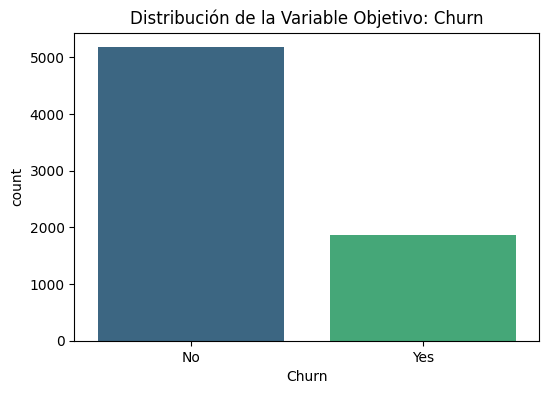

In [45]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Churn', data=df, palette='viridis')
plt.title('Distribución de la Variable Objetivo: Churn')
plt.show()

Interpretación de la Distribución de Churn (Target)
"El gráfico de barras de la variable objetivo Churn muestra una distribución desbalanceada. Aproximadamente el 26% de los clientes han abandonado la compañía (Yes), mientras que el 74% permanece (No)."

El "Insight": Estamos ante un problema clásico de clasificación con clases desbalanceadas.

Conclusión Técnica: Esto implica que, en etapas posteriores, no podemos usar solo la "Exactitud" (Accuracy) como métrica, ya que el modelo podría tender a ignorar a los clientes que se van. La preparación de datos debe enfocarse en resaltar las características de ese 26% para que el modelo aprenda a identificarlos.

# Análisis Exploratorio de Datos (EDA)

Distribuciones numéricas


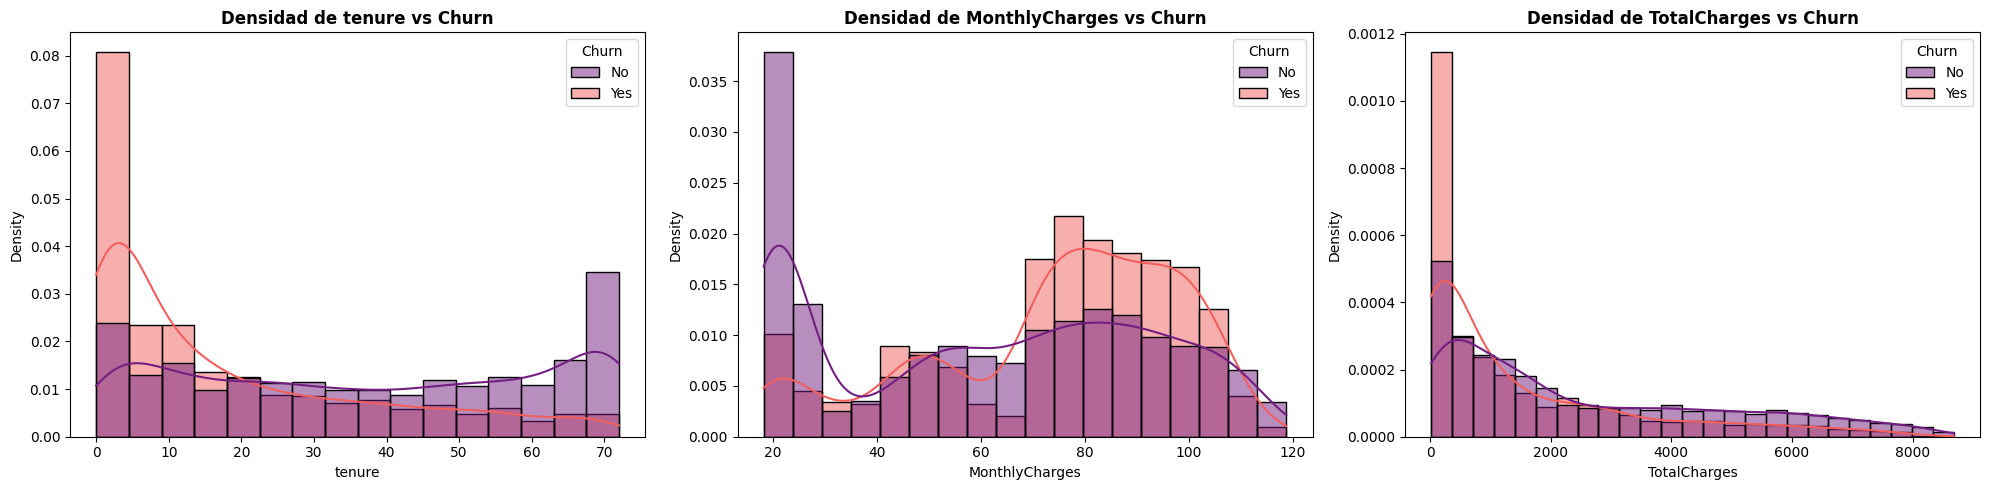

distribuciones categoricas


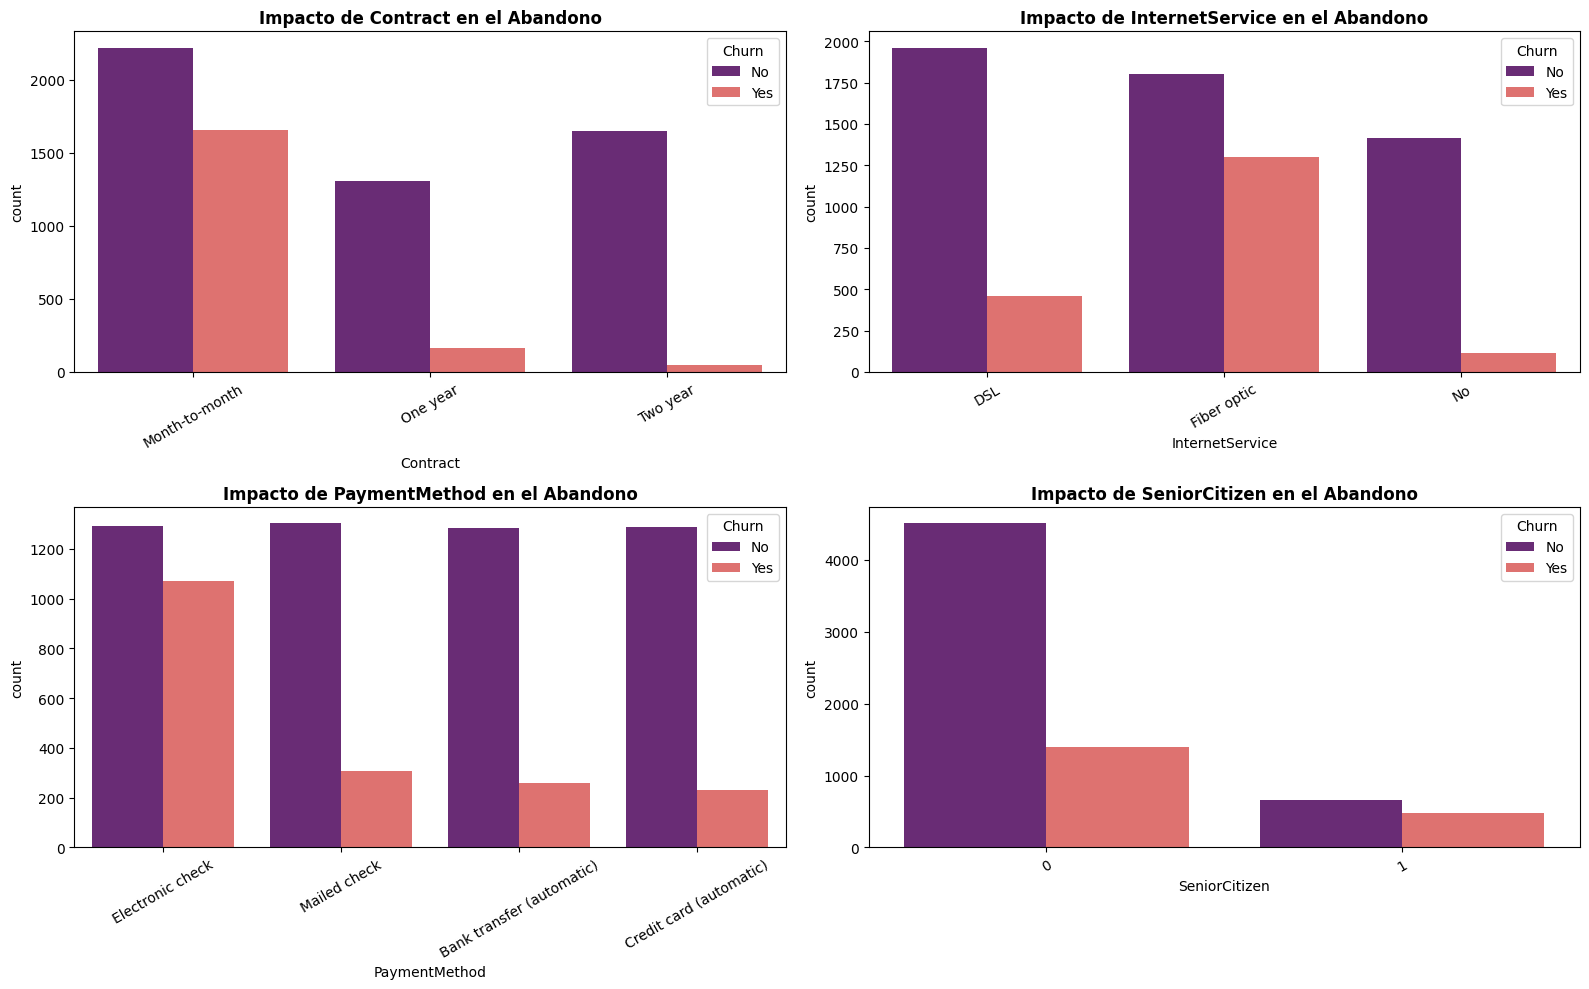

In [46]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

def plot_telco_analysis(df, target_col='Churn'):
    # PREPARACIÓN PREVIA: Aseguramos que TotalCharges sea numérica para el gráfico
    df_plot = df.copy()
    df_plot['TotalCharges'] = pd.to_numeric(df_plot['TotalCharges'], errors='coerce')

    # 1. Variables Numéricas
    print("Distribuciones numéricas")
    num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))
    for i, col in enumerate(num_cols):
        sns.histplot(data=df_plot, x=col, hue=target_col, kde=True, ax=axes[i],
                     stat='density', common_norm=False, palette='magma', alpha=0.5)
        axes[i].set_title(f'Densidad de {col} vs {target_col}', fontweight='bold')
    plt.tight_layout()
    plt.show()
    # 2. Variables Categóricas Clave
    print("distribuciones categoricas")
    # Seleccionamos las que más influyen según la teoría de negocio
    cat_cols = ['Contract', 'InternetService', 'PaymentMethod', 'SeniorCitizen']

    n_rows = 2
    n_cols = 2
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 10))
    axes = axes.flatten()

    for i, col in enumerate(cat_cols):
        # Usamos un gráfico de barras normalizado (proporcional) para ver mejor el impacto
        sns.countplot(data=df_plot, x=col, hue=target_col, ax=axes[i], palette='magma')
        axes[i].set_title(f'Impacto de {col} en el Abandono', fontweight='bold')
        axes[i].tick_params(axis='x', rotation=30)

    plt.tight_layout()
    plt.show()

# Llamada a la función con tu DataFrame filtrado
plot_telco_analysis(df)

Calculando límites IQR y aplicando recorte (Capping) a: ['tenure', 'MonthlyCharges', 'TotalCharges']
Registros originales: 7043
Registros tras el tratamiento: 7043

--------------------------------------------------


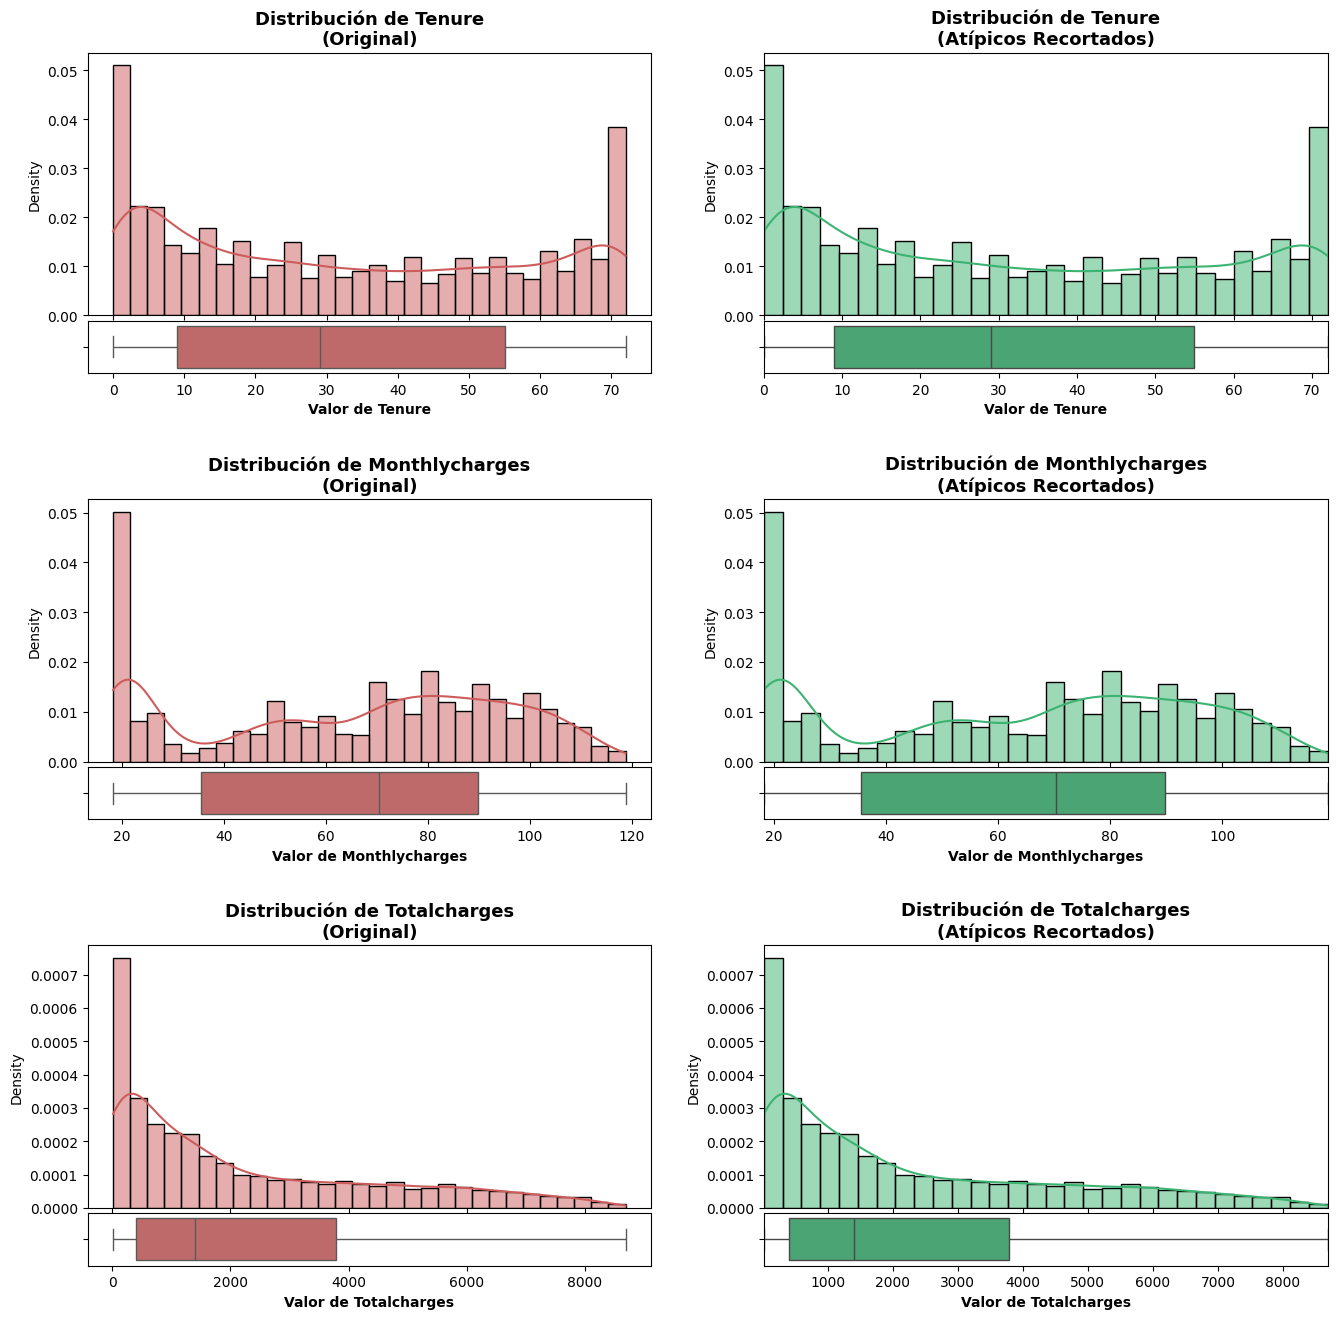

In [54]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Definimos las variables numéricas específicas de tu análisis
numerical_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 2. Creamos copia y aplicamos Capping a estas columnas
df_sin_outliers = df.copy()

print(f"Calculando límites IQR y aplicando recorte (Capping) a: {numerical_cols}")
for col in numerical_cols:
    # Aseguramos que sea numérico para el cálculo
    df_sin_outliers[col] = pd.to_numeric(df_sin_outliers[col], errors='coerce')

    Q1 = df_sin_outliers[col].quantile(0.25)
    Q3 = df_sin_outliers[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Aplicamos el recorte (Capping) usando np.clip
    df_sin_outliers[col] = np.clip(df_sin_outliers[col], lower_bound, upper_bound)

print(f"Registros originales: {len(df)}")
print(f"Registros tras el tratamiento: {len(df_sin_outliers)}\n")
print("-" * 50)

# 3. Visualización Dinámica Avanzada con Ejes Ajustados
fig, axs = plt.subplots(len(numerical_cols), 2, figsize=(16, 5 * len(numerical_cols)))

for i, col in enumerate(numerical_cols):
    nombre_columna = col.capitalize()
    data_orig = pd.to_numeric(df[col], errors='coerce').dropna()
    data_cap = df_sin_outliers[col].dropna()

    # COLUMNA IZQUIERDA: DATOS ORIGINALES
    ax_hist_orig = axs[i, 0]
    ax_hist_orig.set_title(f'Distribución de {nombre_columna}\n(Original)', fontweight='bold', fontsize=13)
    sns.histplot(data_orig, bins=30, kde=True, ax=ax_hist_orig, color='indianred', stat='density')
    ax_hist_orig.set_xlabel('')
    ax_hist_orig.tick_params(labelbottom=False)

    ax_box_orig = ax_hist_orig.inset_axes([0, -0.22, 1, 0.2])
    sns.boxplot(x=data_orig, ax=ax_box_orig, color='indianred', fliersize=3)
    ax_box_orig.set_xlim(ax_hist_orig.get_xlim())
    ax_box_orig.set_xlabel(f'Valor de {nombre_columna}', fontweight='bold')

    # COLUMNA DERECHA: DATOS RECORTADOS (CAPPING) - EJE AJUSTADO
    ax_hist_cap = axs[i, 1]
    ax_hist_cap.set_title(f'Distribución de {nombre_columna}\n(Atípicos Recortados)', fontweight='bold', fontsize=13)
    sns.histplot(data_cap, bins=30, kde=True, ax=ax_hist_cap, color='mediumseagreen', stat='density')
    ax_hist_cap.set_xlabel('')
    ax_hist_cap.tick_params(labelbottom=False)

    ax_box_cap = ax_hist_cap.inset_axes([0, -0.22, 1, 0.2])
    sns.boxplot(x=data_cap, ax=ax_box_cap, color='mediumseagreen', fliersize=3)

    # AJUSTE: Limitamos el eje X al rango de los datos ya recortados para mejorar la visibilidad
    ax_hist_cap.set_xlim(data_cap.min(), data_cap.max())
    ax_box_cap.set_xlim(ax_hist_cap.get_xlim())
    ax_box_cap.set_xlabel(f'Valor de {nombre_columna}', fontweight='bold')

plt.subplots_adjust(hspace=0.7)
plt.show()

In [48]:
# 1. Identificar variables categóricas
categorical_cols = df_sin_outliers.select_dtypes(include=['object', 'category']).columns

df_final = df_sin_outliers.copy()

for col in categorical_cols:
    n_unique = df_final[col].nunique()

    if n_unique == 2:
        # CASO A: Binarias -> Transformar a 0 y 1
        from sklearn.preprocessing import LabelEncoder
        le = LabelEncoder()
        df_final[col] = le.fit_transform(df_final[col])
        print(f"Variable '{col}': Convertida a Binaria (0/1)")

    elif 2 < n_unique <= 10:
        # CASO B: Nominales bajas -> One-Hot Encoding
        df_final = pd.get_dummies(df_final, columns=[col], prefix=col, drop_first=True)
        print(f"Variable '{col}': Aplicado One-Hot Encoding ({n_unique} categorías)")

    else:
        # CASO C: Alta cardinalidad -> Advertencia
        print(f"Variable '{col}': ¡Atención! Alta cardinalidad ({n_unique}). Evaluar agrupar categorías.")

# Convertir booleanos resultantes de get_dummies a 0 y 1 (opcional)
df_final = df_final.replace({True: 1, False: 0})

Variable 'gender': Convertida a Binaria (0/1)
Variable 'Partner': Convertida a Binaria (0/1)
Variable 'InternetService': Aplicado One-Hot Encoding (3 categorías)
Variable 'Contract': Aplicado One-Hot Encoding (3 categorías)
Variable 'PaymentMethod': Aplicado One-Hot Encoding (4 categorías)
Variable 'Churn': Convertida a Binaria (0/1)


/tmp/ipykernel_4823/4162591389.py:26: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_final = df_final.replace({True: 1, False: 0})


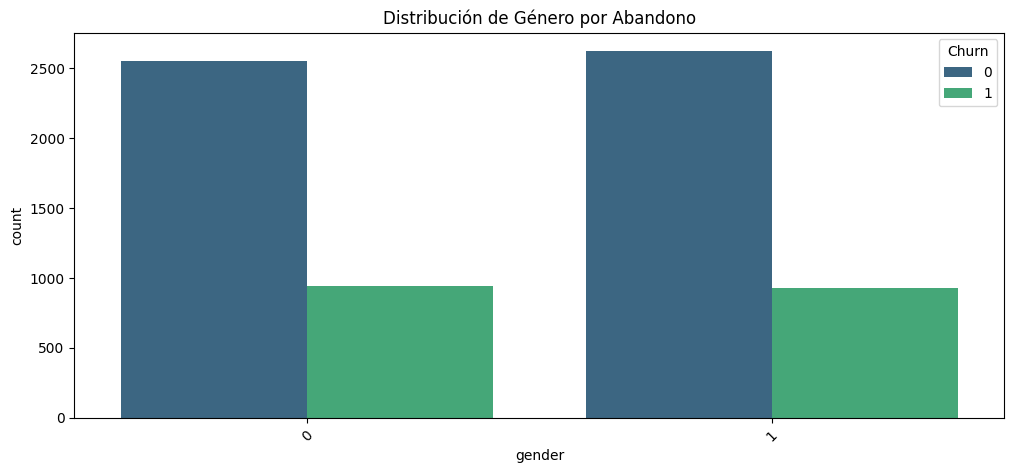

In [51]:
# Ejemplo: Relación de las categorías con la variable objetivo (suponiendo que se llama 'y')
plt.figure(figsize=(12, 5))
sns.countplot(data=df_final, x='gender', hue='Churn', palette='viridis')
plt.title('Distribución de Género por Abandono')
plt.xticks(rotation=45)
plt.show()

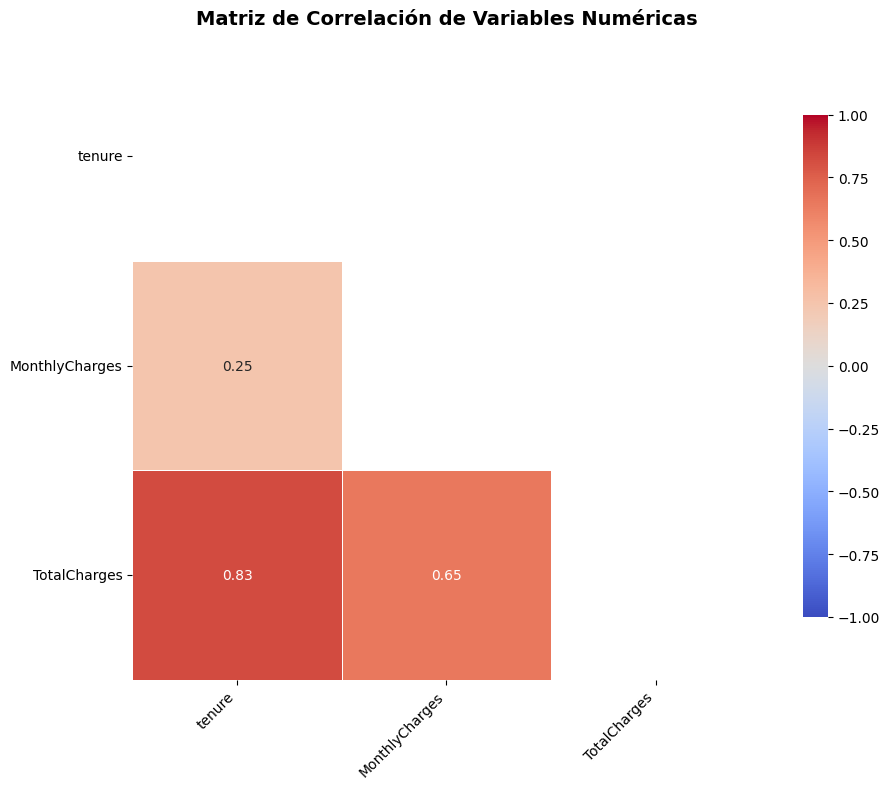

In [52]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Seleccionar solo las variables numéricas de interés del DataFrame df_sin_outliers
num_cols_corr = ['tenure', 'MonthlyCharges', 'TotalCharges']

# 2. Calcular la matriz de correlación de Pearson
matriz_correlacion = df_sin_outliers[num_cols_corr].corr()

# --- EL TRUCO VISUAL: Crear una máscara para el triángulo superior ---
# np.triu_indices_from devuelve los índices del triángulo superior
mask = np.zeros_like(matriz_correlacion, dtype=bool)
mask[np.triu_indices_from(mask)] = True

# 3. Configurar la visualización
plt.figure(figsize=(10, 8))

# Generar un Heatmap aplicando la máscara (mask=mask)
sns.heatmap(matriz_correlacion,
            mask=mask,               # <--- Aplicamos la máscara aquí
            annot=True,
            cmap="coolwarm",
            fmt=".2f",
            linewidths=0.5,
            vmin=-1,
            vmax=1,
            square=True,
            cbar_kws={"shrink": .8})

plt.title("Matriz de Correlación de Variables Numéricas", fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()